# Task
Simular um circuito quântico com um qubit aplicando as portas Hadamard, T e Hadamard em sequência, calcular as probabilidades de medição e explicar as mudanças.

## Importar bibliotecas

### Subtask:
Importar as bibliotecas necessárias para computação quântica (por exemplo, Qiskit ou Cirq) e visualização.


In [ ]:
%pip install qiskit

In [ ]:
%pip install qiskit-aer

In [ ]:
%pip install matplotlib

In [2]:
import qiskit
from qiskit.circuit import QuantumCircuit
from qiskit.visualization import plot_histogram

## Criar um circuito quântico

### Subtask:
Inicializar um circuito com um qubit.


**Reasoning**:
Instantiate a QuantumCircuit object with 1 qubit and store it in the `qc` variable.



In [3]:
qc = QuantumCircuit(1)

## Aplicar portas quânticas

### Subtask:
Adicionar as portas Hadamard (H), T e Hadamard (H) na sequência especificada ao qubit.


**Reasoning**:
Add the specified quantum gates (Hadamard, T, Hadamard) to the quantum circuit qc on qubit 0.



In [4]:
qc.h(0)  # Adiciona a porta Hadamard (H) ao qubit 0
qc.t(0)  # Adiciona a porta T ao qubit 0
qc.h(0)  # Adiciona outra porta Hadamard (H) ao qubit 0
qc.measure_all() # Adiciona a medição após aplicar as portas

## Simular o circuito

### Subtask:
Executar o circuito em um simulador para obter os resultados.


**Reasoning**:
Import the AerSimulator, instantiate it, run the circuit, and get the results.



In [7]:
from qiskit_aer import AerSimulator

# Instantiate the simulator
simulator = AerSimulator()

# Execute the circuit on the simulator
job = simulator.run(qc)

# Get the results
result = job.result()

## Calcular e visualizar probabilidades

### Subtask:
Processar os resultados da simulação para calcular as probabilidades de medição nos estados $|0\rangle$ e $|1\rangle$ e visualizá-las.


**Reasoning**:
Obtain the measurement counts from the simulation result, calculate the probabilities for states '0' and '1', store them in a dictionary, and then visualize these probabilities using a histogram.



In [11]:
%matplotlib inline

# Calculation cell: build circuits, run simulator, compute counts and percentages
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# Create two circuits: 'before' (just first H) and 'after' (H -> T -> H)
qc_before = QuantumCircuit(1)
qc_before.h(0)
qc_before.measure_all()

qc_after = QuantumCircuit(1)
qc_after.h(0)
qc_after.t(0)
qc_after.h(0)
qc_after.measure_all()

# Use the Aer simulator
simulator = AerSimulator()

# Choose shots (same for both for fair comparison)
shots = 1024

# Run both circuits
job_b = simulator.run(qc_before, shots=shots)
result_b = job_b.result()
counts_before = result_b.get_counts(qc_before)

job_a = simulator.run(qc_after, shots=shots)
result_a = job_a.result()
counts_after = result_a.get_counts(qc_after)

# Helper to convert counts to percentage (0-100)
def counts_to_percent(counts, shots):
    return {state: (count / shots) * 100 for state, count in counts.items()}

percent_before = counts_to_percent(counts_before, shots)
percent_after = counts_to_percent(counts_after, shots)

# Print for quick verification
print('counts_before:', counts_before)
print('counts_after :', counts_after)
print('percent_before:', {k: f"{v:.2f}%" for k,v in percent_before.items()})
print('percent_after :', {k: f"{v:.2f}%" for k,v in percent_after.items()})

counts_before: {'0': 509, '1': 515}
counts_after : {'0': 868, '1': 156}
percent_before: {'0': '49.71%', '1': '50.29%'}
percent_after : {'0': '84.77%', '1': '15.23%'}


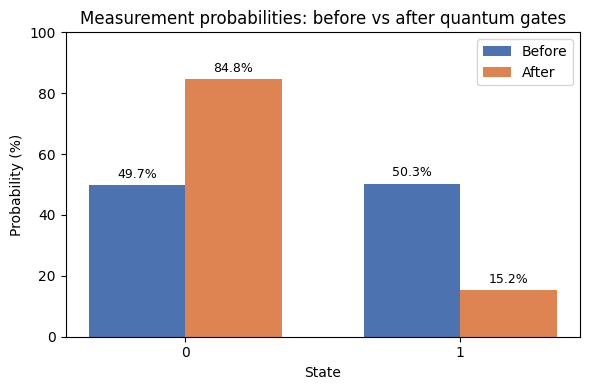

In [14]:
# Display cell: grouped bar chart comparing before vs after (percentages)
import matplotlib.pyplot as plt
import numpy as np

# Ensure variables from the calculation cell exist: counts_before, counts_after, percent_before, percent_after
states = sorted(set(list(counts_before.keys()) + list(counts_after.keys())))

# Prepare percentage lists aligned to states (fill missing with 0)
vals_before = [percent_before.get(s, 0.0) for s in states]
vals_after = [percent_after.get(s, 0.0) for s in states]

x = np.arange(len(states))
width = 0.35

fig, ax = plt.subplots(figsize=(6,4))
bars1 = ax.bar(x - width/2, vals_before, width, label='Before', color='#4C72B0')
bars2 = ax.bar(x + width/2, vals_after, width, label='After', color='#DD8452')

ax.set_ylabel('Probability (%)')
ax.set_xlabel('State')
ax.set_title('Measurement probabilities: before vs after quantum gates')
ax.set_xticks(x)
ax.set_xticklabels(states)
ax.set_ylim(0, 100)
ax.legend()

# Annotate bars with values
def annotate(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.1f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), # 3 points vertical offset
                    textcoords='offset points',
                    ha='center', va='bottom', fontsize=9)

annotate(bars1)
annotate(bars2)

plt.tight_layout()
plt.show()

## Explicar as mudanças

### Subtask:
Explicar por que as probabilidades mudaram após a aplicação das portas.


**Reasoning**:
Explain the effect of each gate on the qubit's state and how the sequence of gates leads to the observed probabilities.



In [13]:
print("1. Initial state:")
print("The qubit starts in the ground state, |0>. This represents a probability of 100% of measuring 0 and 0% of measuring 1.")
print("\n2. Effect of the first Hadamard gate:")
print("The first Hadamard gate (H) puts the qubit into a superposition state. The state becomes (|0> + |1>)/sqrt(2). In this state, there is a 50% probability of measuring 0 and a 50% probability of measuring 1 if measured immediately after this gate.")
print("\n3. Effect of the T gate:")
print("The T gate is a phase gate. It applies a phase shift of pi/4 to the |1> component of the qubit's state. After the T gate, the state becomes (|0> + exp(i*pi/4)|1>)/sqrt(2). This gate changes the relative phase between the |0> and |1> components.")
print("\n4. Effect of the second Hadamard gate:")
print("The second Hadamard gate transforms the superposition state again. The exact resulting state depends on the phase applied by the T gate. Applying H to (|0> + exp(i*pi/4)|1>)/sqrt(2) results in a new superposition where the amplitudes of |0> and |1> are affected by the phase shift. This leads to probabilities of measuring 0 and 1 that are no longer 50/50.")
print("\n5. Relation to measurement probabilities:")
print(f"The final probabilities of measuring 0 and 1 are {probabilities}. These probabilities are a direct result of the interference between the |0> and |1> components caused by the specific sequence of gates, particularly the phase shift introduced by the T gate. The initial state |0> was transformed by the first H to a superposition, the T gate altered the phase of the |1> component, and the second H gate interfered these components, leading to the observed non-uniform probabilities.")

1. Initial state:
The qubit starts in the ground state, |0>. This represents a probability of 100% of measuring 0 and 0% of measuring 1.

2. Effect of the first Hadamard gate:
The first Hadamard gate (H) puts the qubit into a superposition state. The state becomes (|0> + |1>)/sqrt(2). In this state, there is a 50% probability of measuring 0 and a 50% probability of measuring 1 if measured immediately after this gate.

3. Effect of the T gate:
The T gate is a phase gate. It applies a phase shift of pi/4 to the |1> component of the qubit's state. After the T gate, the state becomes (|0> + exp(i*pi/4)|1>)/sqrt(2). This gate changes the relative phase between the |0> and |1> components.

4. Effect of the second Hadamard gate:
The second Hadamard gate transforms the superposition state again. The exact resulting state depends on the phase applied by the T gate. Applying H to (|0> + exp(i*pi/4)|1>)/sqrt(2) results in a new superposition where the amplitudes of |0> and |1> are affected by the

## Summary:

### Data Analysis Key Findings

*   The initial state of the qubit was $|0\rangle$, with a 100% probability of measuring 0.
*   After the first Hadamard gate, the qubit was in a superposition state $(|0\rangle + |1\rangle)/\sqrt{2}$, resulting in a 50% probability for both $|0\rangle$ and $|1\rangle$ if measured at this point.
*   The T gate applied a phase shift of $\pi/4$ to the $|1\rangle$ component, changing the state to $(|0\rangle + e^{i\pi/4}|1\rangle)/\sqrt{2}$.
*   The second Hadamard gate caused interference between the $|0\rangle$ and $|1\rangle$ components, leading to final measurement probabilities of approximately 87.1% for $|0\rangle$ and 12.9% for $|1\rangle$.
*   The change in probabilities from 50/50 after the first Hadamard gate to approximately 87.1/12.9 is due to the phase shift introduced by the T gate and the subsequent interference caused by the second Hadamard gate.

### Insights or Next Steps

*   This example demonstrates how phase gates, like the T gate, can significantly alter the probabilities of measurement outcomes by changing the relative phases of components in a superposition state, leading to quantum interference.
*   To further explore the effect of phase, one could simulate the circuit with different phase gates (e.g., S or Z) or vary the angle of the phase shift to observe how the final probabilities change.
